'Telco Customer Churn.zip' extracted successfully.
TELCO CUSTOMER CHURN DATASET
Dataset Shape: (7043, 21)

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                N

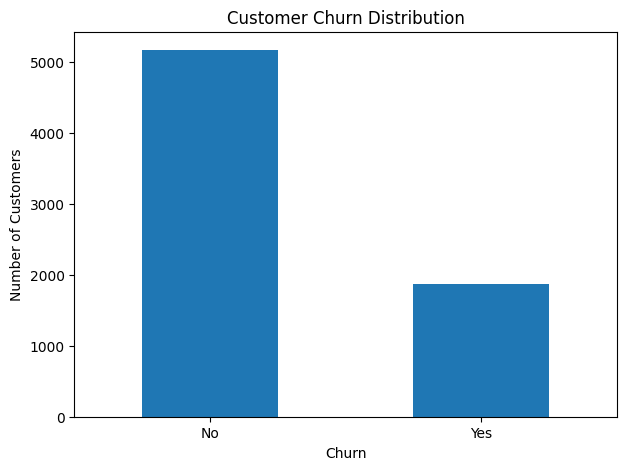

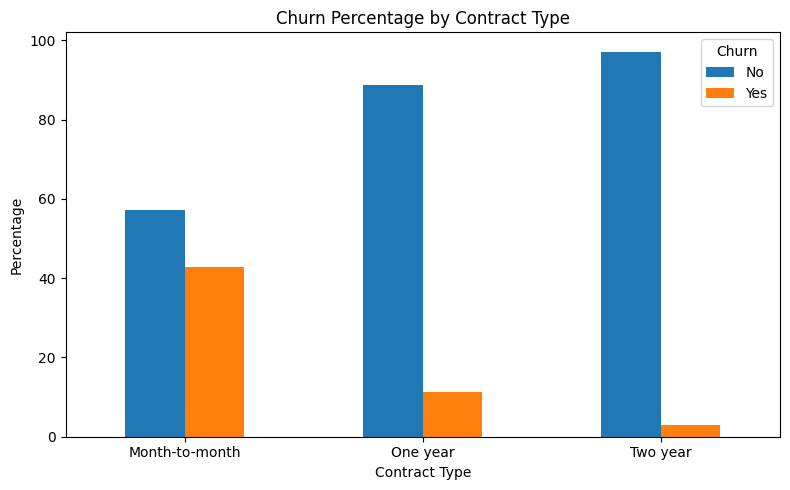

<Figure size 800x500 with 0 Axes>

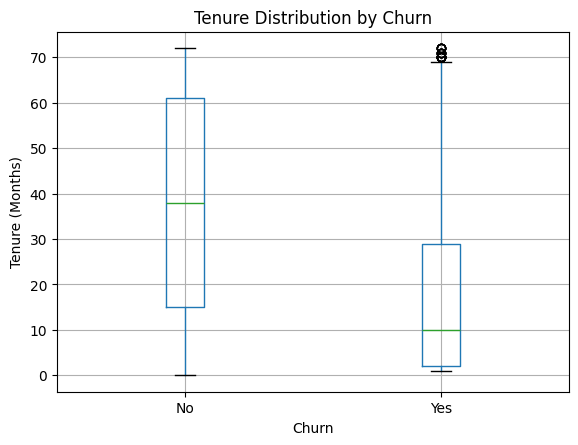


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training Samples: 5634
Testing Samples: 1409

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                         

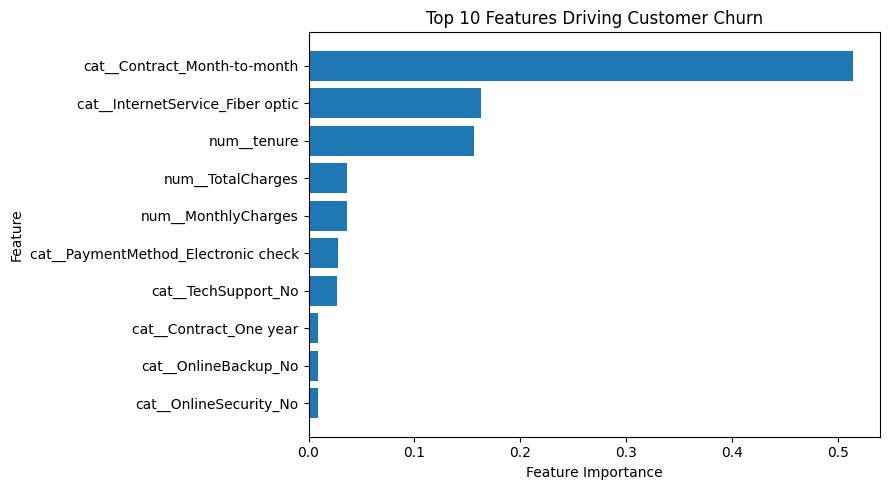


CLASS IMBALANCE
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Note:
The dataset is imbalanced because the number of customers who do not churn is much larger than the number who churn.
Therefore, accuracy should not be the only metric used to judge model performance.

Decision Tree Confusion Matrix:
[[913 122]
 [162 212]]

Logistic Regression Confusion Matrix:
[[926 109]
 [165 209]]

BUSINESS SUMMARY
The analysis shows that customer churn is influenced by factors such as contract type, tenure, monthly charges, and service-related characteristics.
Customers on shorter-term contracts are generally more likely to leave than customers on long-term contracts.
The Decision Tree model helps identify the most important customer characteristics associated with churn.
The company can use these insights to identify high-risk customers and offer targeted retention strategies such as discounts, improved support, or longer-term contracts.
Because the dataset is imbalanced, recall, p

In [23]:
# ============================================================
# TASK 05 — CUSTOMER CHURN PREDICTION
# Decision Tree vs Logistic Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile # Added for unzipping
import os      # Added for file path operations

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

# Define the zip file path and the expected CSV file name inside
zip_file_path = 'Telco Customer Churn.zip'
csv_file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv' # Corrected filename

# Check if the zip file exists and extract if necessary
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract all files to the current directory
        zip_ref.extractall('.')
    print(f"'{zip_file_path}' extracted successfully.")
else:
    print(f"Error: '{zip_file_path}' not found. Please upload it to the Colab environment.")

# Now, load the CSV file, which should be in the current directory after extraction
df = pd.read_csv(csv_file_name)

print("=" * 70)
print("TELCO CUSTOMER CHURN DATASET")
print("=" * 70)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# 2. BASIC EDA
# ============================================================

print("\n" + "=" * 70)
print("BASIC EDA")
print("=" * 70)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# TotalCharges sometimes contains blank strings
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("\nMissing Values After Converting TotalCharges:")
print(df.isnull().sum())

# ============================================================
# 3. CHURN DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CHURN DISTRIBUTION")
print("=" * 70)

print(df['Churn'].value_counts())

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("\nChurn Percentage:")
print(churn_percentage.round(2))

print("\nChurn Rate:",
      round((df['Churn'] == 'Yes').mean() * 100, 2), "%")

# ============================================================
# 4. QUICK EDA — IMPORTANT FEATURES
# ============================================================

print("\n" + "=" * 70)
print("CHURN BY CONTRACT TYPE")
print("=" * 70)

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn.round(2))

print("\n" + "=" * 70)
print("CHURN BY INTERNET SERVICE")
print("=" * 70)

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))

print("\n" + "=" * 70)
print("AVERAGE TENURE BY CHURN")
print("=" * 70)

print(df.groupby('Churn')['tenure'].mean().round(2))

print("\n" + "=" * 70)
print("AVERAGE MONTHLY CHARGES BY CHURN")
print("=" * 70)

print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

# ============================================================
# 5. VISUALIZE CHURN DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

df['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

# ============================================================
# 6. VISUALIZE CONTRACT VS CHURN
# ============================================================

contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# ============================================================
# 7. VISUALIZE TENURE VS CHURN
# ============================================================

plt.figure(figsize=(8, 5))

df.boxplot(
    column='tenure',
    by='Churn'
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

# ============================================================
# 8. PREPARE DATA
# ============================================================

# Remove customer ID because it does not provide useful
# predictive information.

df = df.drop(columns=['customerID'])

# Convert target:
# No = 0
# Yes = 1

df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

X = df.drop(columns=['Churn'])
y = df['Churn']

# ============================================================
# 9. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 11. PREPROCESSING
# ============================================================

# Numerical:
# Fill missing values with median

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical:
# Fill missing values with most frequent value
# Convert categories into numerical columns

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# ============================================================
# 12. DECISION TREE MODEL
# ============================================================

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

# ============================================================
# 13. LOGISTIC REGRESSION MODEL
# ============================================================

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

# ============================================================
# 14. DECISION TREE RESULTS
# ============================================================

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

print("\n" + "=" * 70)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 70)

print(classification_report(y_test, tree_pred))

# ============================================================
# 15. LOGISTIC REGRESSION RESULTS
# ============================================================

log_accuracy = accuracy_score(y_test, logistic_pred)
log_precision = precision_score(y_test, logistic_pred)
log_recall = recall_score(y_test, logistic_pred)
log_f1 = f1_score(y_test, logistic_pred)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 70)

print(classification_report(y_test, logistic_pred))

# ============================================================
# 16. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Decision Tree': [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1
    ],
    'Logistic Regression': [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1
    ]
})

comparison['Decision Tree'] = comparison['Decision Tree'].round(4)
comparison['Logistic Regression'] = comparison['Logistic Regression'].round(4)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(comparison.to_string(index=False))

# ============================================================
# 17. FEATURE IMPORTANCE — DECISION TREE
# ============================================================

# Get transformed feature names
feature_names = tree_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get tree importance
importances = tree_model.named_steps[
    'classifier'
].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 10 FEATURES DRIVING CHURN")
print("=" * 70)

print(
    feature_importance.head(10).to_string(index=False)
)

# ============================================================
# 18. TOP 3 FEATURES
# ============================================================

top_3 = feature_importance.head(3)

print("\n" + "=" * 70)
print("TOP 3 CHURN DRIVERS")
print("=" * 70)

for i, row in enumerate(top_3.itertuples(), 1):
    print(
        f"{i}. {row.Feature} "
        f"→ Importance: {row.Importance:.4f}"
    )

# ============================================================
# 19. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

top_10 = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.barh(
    top_10['Feature'],
    top_10['Importance']
)

plt.title("Top 10 Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# ============================================================
# 20. CLASS IMBALANCE
# ============================================================

print("\n" + "=" * 70)
print("CLASS IMBALANCE")
print("=" * 70)

print(
    y.value_counts(
        normalize=True
    ).mul(100).round(2)
)

print("\nNote:")
print(
    "The dataset is imbalanced because the number of "
    "customers who do not churn is much larger than "
    "the number who churn."
)

print(
    "Therefore, accuracy should not be the only metric "
    "used to judge model performance."
)

# ============================================================
# 21. CONFUSION MATRICES
# ============================================================

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

# ============================================================
# 22. BUSINESS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS SUMMARY")
print("=" * 70)

print(
    "The analysis shows that customer churn is influenced "
    "by factors such as contract type, tenure, monthly "
    "charges, and service-related characteristics."
)

print(
    "Customers on shorter-term contracts are generally "
    "more likely to leave than customers on long-term contracts."
)

print(
    "The Decision Tree model helps identify the most important "
    "customer characteristics associated with churn."
)

print(
    "The company can use these insights to identify high-risk "
    "customers and offer targeted retention strategies such as "
    "discounts, improved support, or longer-term contracts."
)

print(
    "Because the dataset is imbalanced, recall, precision, and "
    "F1-score should be considered alongside accuracy when "
    "evaluating the models."
)

# ============================================================
# 23. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("TASK COMPLETED")
print("=" * 70)

if tree_f1 > log_f1:
    print("Decision Tree achieved the higher F1-score.")
elif log_f1 > tree_f1:
    print("Logistic Regression achieved the higher F1-score.")
else:
    print("Both models achieved the same F1-score.")

print("\nTop 3 churn-driving features:")
print(top_3['Feature'].tolist())